# 06 Final decision charts

This notebook creates the compact visual outputs used to
communicate the candidate shortlist and recommendation. It
reads exported analysis tables rather than repeating the
cleaning or scoring logic.

## 1. Imports and final outputs

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, TABLES_DIR
from src.utils import save_figure, validate_required_columns

sns.set_theme(style="whitegrid", context="notebook")
shortlist = pd.read_csv(
    TABLES_DIR / "rent_inclusive_pilot_ranking.csv"
)
final_shortlist = pd.read_csv(TABLES_DIR / "final_shortlist.csv")

validate_required_columns(
    shortlist,
    {
        "parish",
        "pilot_opportunity_score",
        "median_rent_eur_m2_month",
        "rent_sample_size",
    },
)
validate_required_columns(
    final_shortlist,
    {
        "parish",
        "pilot_opportunity_score",
        "top1_share",
        "top3_share",
        "recommendation_role",
    },
)

## 2. Rent-inclusive candidate ranking

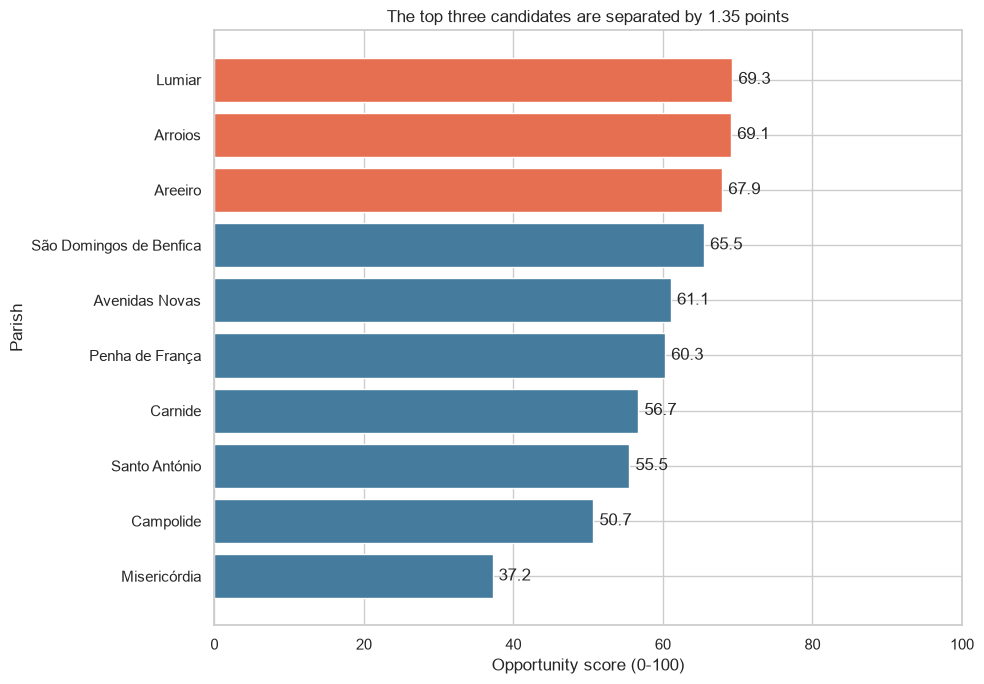

In [2]:
ranking_chart = shortlist.sort_values(
    "pilot_opportunity_score"
)
colors = [
    "#E76F51"
    if parish in {"Areeiro", "Arroios", "Lumiar"}
    else "#457B9D"
    for parish in ranking_chart["parish"]
]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    ranking_chart["parish"],
    ranking_chart["pilot_opportunity_score"],
    color=colors,
)
ax.set_title("The top three candidates are separated by 1.35 points")
ax.set_xlabel("Opportunity score (0-100)")
ax.set_ylabel("Parish")
ax.set_xlim(0, 100)
for index, value in enumerate(
    ranking_chart["pilot_opportunity_score"]
):
    ax.text(value + 0.8, index, f"{value:.1f}", va="center")
fig.tight_layout()
ranking_path = FIGURES_DIR / "10_rent_inclusive_shortlist.png"
save_figure(fig, ranking_path)
plt.show()

## 3. Score, rent and sample coverage

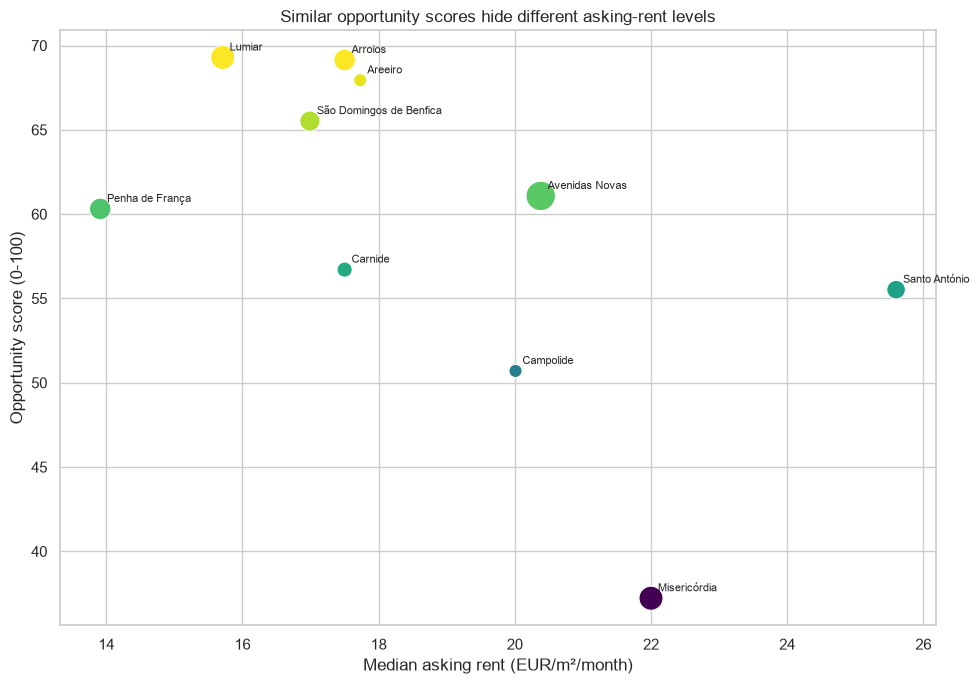

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=shortlist,
    x="median_rent_eur_m2_month",
    y="pilot_opportunity_score",
    size="rent_sample_size",
    hue="pilot_opportunity_score",
    palette="viridis",
    sizes=(90, 450),
    legend=False,
    ax=ax,
)
for row in shortlist.itertuples():
    ax.annotate(
        row.parish,
        (
            row.median_rent_eur_m2_month,
            row.pilot_opportunity_score,
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )
ax.set_title(
    "Similar opportunity scores hide different asking-rent levels"
)
ax.set_xlabel("Median asking rent (EUR/m²/month)")
ax.set_ylabel("Opportunity score (0-100)")
fig.tight_layout()
tradeoff_path = FIGURES_DIR / "11_score_vs_asking_rent.png"
save_figure(fig, tradeoff_path)
plt.show()

## 4. Final recommendation summary

In [4]:
display(
    final_shortlist[
        [
            "recommendation_role",
            "parish",
            "pilot_opportunity_score",
            "top1_share",
            "top3_share",
            "median_rent_eur_m2_month",
            "rent_sample_size",
        ]
    ]
)
print("Close shortlist: Areeiro, Arroios and Lumiar")
print(
    "Recommendation status: compare real opportunities across "
    "all three areas; no strict internal ranking."
)

,recommendation_role,parish,pilot_opportunity_score,top1_share,top3_share,median_rent_eur_m2_month,rent_sample_size
0,shortlist,Lumiar,69.29,48.24,79.30,15.71,17
1,shortlist,Arroios,69.14,46.48,77.36,17.50,15
2,shortlist,Areeiro,67.94,5.26,83.82,17.73,10


Close shortlist: Areeiro, Arroios and Lumiar
Recommendation status: compare real opportunities across all three areas; no strict internal ranking.


Areeiro, Arroios and Lumiar form one close search scope because
they offer different rent, demand and competition trade-offs.
Their internal score order is not treated as a definitive
business ranking. The company can compare real opportunities
across all three areas in parallel.